Inputs shape: (17, 2)
Outputs shape: (17,)
First 20 rows of raw data:
    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
15    0.472352    1.055087     -1.802279e-144  week-6
16    0.523861    1.067166     -1.315157e-142  week-7
14    0.469395    1.050091     -6.688485e-142  week-5
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.6501

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/data/BaseDataHandler.py:134: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_copy = pd.concat([df, new_df], ignore_index=True)


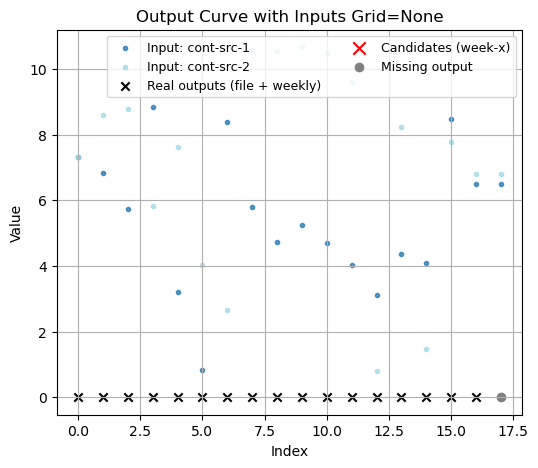

Saved LLM candidates to: results/run_2025-12-19 03-20-00/df_llm_candidates.csv

Pipeline finished.
Pipeline finished. Results keys: ['llm']


In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))